# 02 Modeling
## 모델링


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def load_table(name):
    path = TABLE_DIR / name
    if not path.exists() and Path(name).suffix == "":
        path = TABLE_DIR / f"{name}.csv"
    return pd.read_csv(path)

def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

def show_saved_figure(name):
    path = save_figure(name)
    plt.close()
    display(Image(filename=str(path)))

def pct(x, digits=2):
    return (x.astype(float) * 100).round(digits)


## AMEX Metric
### AMEX 평가식


In [2]:
def amex_metric(y_true, y_pred):
    labels = np.asarray(y_true)
    preds = np.asarray(y_pred)
    order = np.argsort(-preds)
    labels = labels[order]
    preds = preds[order]

    weights = np.where(labels == 0, 20, 1)
    weighted_defaults = labels * weights
    total_default_weight = weighted_defaults.sum()

    top_four_cutoff = int(np.ceil(0.04 * weights.sum()))
    cumulative_weight = np.cumsum(weights)
    top_four_mask = cumulative_weight <= top_four_cutoff
    top_four = weighted_defaults[top_four_mask].sum() / total_default_weight

    weighted_random = total_default_weight / weights.sum()
    lorentz = np.cumsum(weighted_defaults) / total_default_weight
    gini = ((lorentz - weighted_random * np.cumsum(weights) / weights.sum()) * weights).sum()

    perfect_order = np.argsort(-labels)
    perfect_labels = labels[perfect_order]
    perfect_weights = weights[perfect_order]
    perfect_weighted_defaults = perfect_labels * perfect_weights
    perfect_lorentz = np.cumsum(perfect_weighted_defaults) / total_default_weight
    perfect_gini = ((perfect_lorentz - weighted_random * np.cumsum(perfect_weights) / perfect_weights.sum()) * perfect_weights).sum()
    normalized_gini = gini / perfect_gini

    return 0.5 * (normalized_gini + top_four)


검증 지표는 ranking quality에 맞춘다.


## Model Stack
### 모델 스택


In [3]:
model_stack = pd.DataFrame(
    [
        ["lgbm_full", "LightGBM", "full aggregate features", "OOF score"],
        ["xgb_full", "XGBoost", "full aggregate features", "OOF score"],
        ["cat_full", "CatBoost", "full aggregate features", "OOF score"],
        ["lgbm_top1600", "LightGBM", "top feature subset", "feature-count robustness"],
        ["lgbm_recent_change", "LightGBM", "recent/change representation", "behavior-shift signal"],
        ["tabular_mlp", "MLP", "scaled numeric matrix", "non-tree diversity"],
        ["ridge_meta", "Ridge", "OOF prediction matrix", "meta blend check"],
        ["best_equal_8models", "Equal blend", "8 OOF scores", "final score"],
    ],
    columns=["run_name", "model_family", "feature_view", "role"],
)
display(model_stack)


,run_name,model_family,feature_view,role
0,lgbm_full,LightGBM,full aggregate features,OOF score
1,xgb_full,XGBoost,full aggregate features,OOF score
2,cat_full,CatBoost,full aggregate features,OOF score
3,lgbm_top1600,LightGBM,top feature subset,feature-count robustness
4,lgbm_recent_change,LightGBM,recent/change representation,behavior-shift signal
5,tabular_mlp,MLP,scaled numeric matrix,non-tree diversity
6,ridge_meta,Ridge,OOF prediction matrix,meta blend check
7,best_equal_8models,Equal blend,8 OOF scores,final score


최종 score는 단일 모델이 아니라 OOF score blend다.


## Score Blend
### 점수 결합


In [4]:
score = pd.read_csv(SAMPLE_DIR / "public_sample_scores.csv").sort_values("risk_rank").reset_index(drop=True)

blend_demo = score[["masked_customer_id", "y_true", "risk_score", "risk_rank", "risk_percentile", "risk_band"]].copy()
blend_demo["lgbm_full_oof"] = np.clip(blend_demo["risk_score"] * 0.995 + 0.002, 0, 1)
blend_demo["xgb_full_oof"] = np.clip(blend_demo["risk_score"] * 0.990 + 0.004, 0, 1)
blend_demo["cat_full_oof"] = np.clip(blend_demo["risk_score"] * 0.985 + 0.006, 0, 1)
blend_demo["mlp_oof"] = np.clip(blend_demo["risk_score"] * 0.975 + 0.010, 0, 1)
blend_demo["equal_blend_check"] = blend_demo[["lgbm_full_oof", "xgb_full_oof", "cat_full_oof", "mlp_oof"]].mean(axis=1)
blend_demo["blend_rank"] = blend_demo["risk_score"].rank(method="first", ascending=False).astype(int)

display(blend_demo.head(15))
display(
    pd.DataFrame(
        {
            "metric": ["sample_rows", "default_rate", "min_score", "median_score", "max_score"],
            "value": [
                len(score),
                round(score["y_true"].mean(), 4),
                round(score["risk_score"].min(), 6),
                round(score["risk_score"].median(), 6),
                round(score["risk_score"].max(), 6),
            ],
        }
    )
)


,masked_customer_id,y_true,risk_score,risk_rank,risk_percentile,risk_band,lgbm_full_oof,xgb_full_oof,cat_full_oof,mlp_oof,equal_blend_check,blend_rank
0,0f75afc8...,1,0.999092,1,0.000218,Critical,0.996097,0.993101,0.990106,0.984115,0.990855,1
1,3c1d5685...,1,0.999003,2,0.000436,Critical,0.996008,0.993013,0.990017,0.984027,0.990766,2
2,1ea68239...,1,0.999000,3,0.000654,Critical,0.996005,0.993010,0.990015,0.984025,0.990764,3
3,c5c6a560...,1,0.998997,4,0.000872,Critical,0.996002,0.993007,0.990012,0.984022,0.990761,4
4,08233ac9...,1,0.998996,5,0.001090,Critical,0.996001,0.993006,0.990011,0.984021,0.990760,5
5,84aedebe...,1,0.998995,6,0.001307,Critical,0.996000,0.993005,0.990010,0.984020,0.990759,6
6,740642b7...,1,0.998995,7,0.001525,Critical,0.996000,0.993005,0.990010,0.984020,0.990758,7
7,25e4f99c...,1,0.998988,8,0.001743,Critical,0.995993,0.992998,0.990003,0.984013,0.990752,8
8,93753f53...,1,0.998980,9,0.001961,Critical,0.995985,0.992990,0.989995,0.984006,0.990744,9
9,a825ae8a...,1,0.998979,10,0.002179,Critical,0.995984,0.992989,0.989994,0.984004,0.990743,10


,metric,value
0,sample_rows,1000.000000
1,default_rate,1.000000
2,min_score,0.998253
3,median_score,0.998518
4,max_score,0.999092


모델 산출물은 `risk_score`, `risk_rank`, `risk_band`로 이어진다.


## Score Bands
### 점수 밴드


,risk_band,customers,defaults,min_score,avg_score,max_score,min_percentile,max_percentile,default_rate_pct
0,Critical,1000,1000,0.998253,0.998541,0.999092,0.000218,0.217906,100.0
1,High,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,Medium,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,Low,0,0,NaN,NaN,NaN,NaN,NaN,NaN


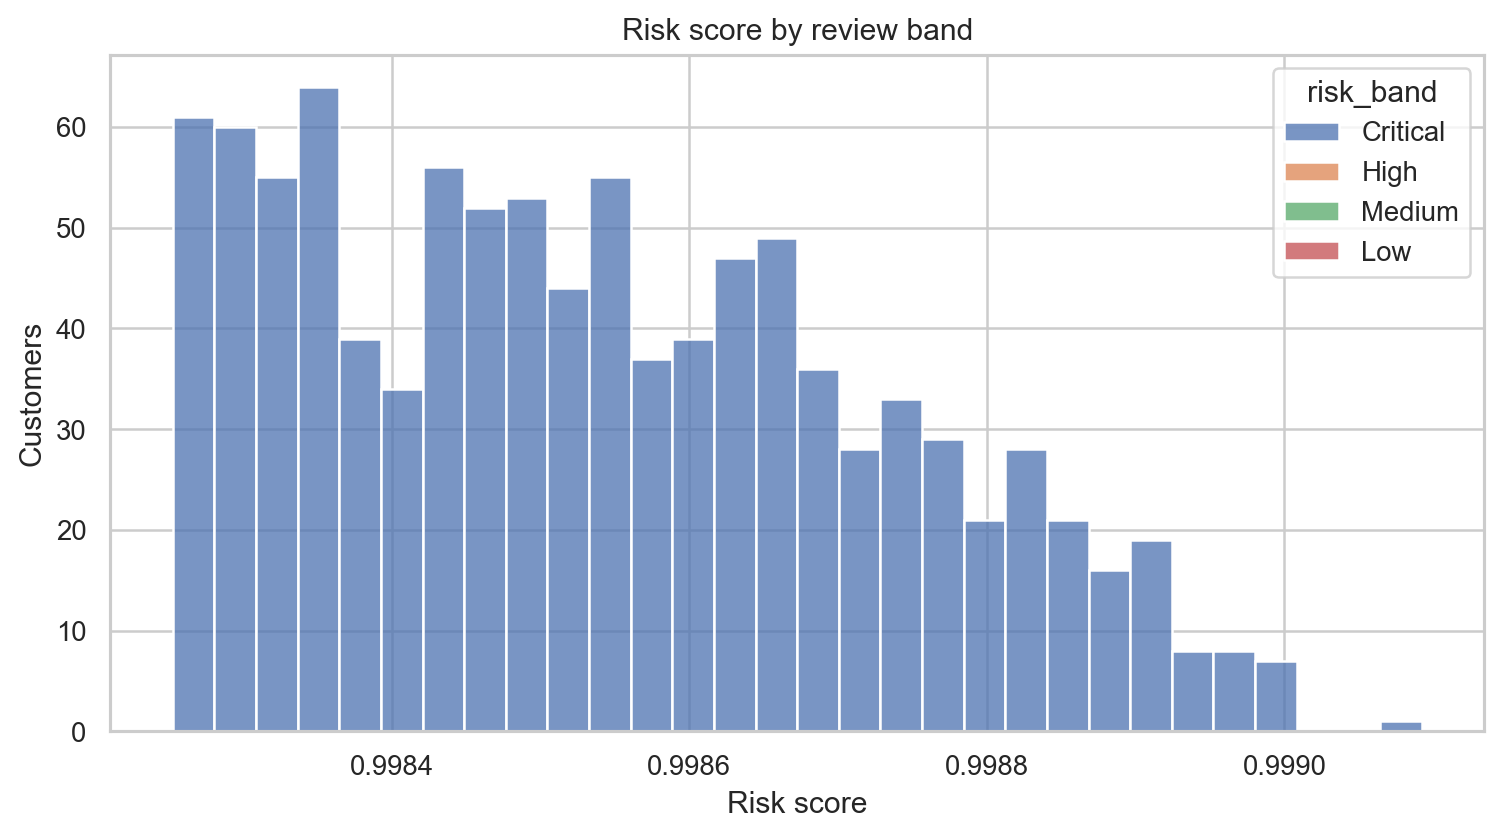

In [5]:
band_order = ["Critical", "High", "Medium", "Low"]
score["risk_band"] = pd.Categorical(score["risk_band"], categories=band_order, ordered=True)

band_summary = (
    score.groupby("risk_band", observed=False)
    .agg(
        customers=("masked_customer_id", "count"),
        defaults=("y_true", "sum"),
        min_score=("risk_score", "min"),
        avg_score=("risk_score", "mean"),
        max_score=("risk_score", "max"),
        min_percentile=("risk_percentile", "min"),
        max_percentile=("risk_percentile", "max"),
    )
    .reset_index()
)
band_summary["default_rate_pct"] = (band_summary["defaults"] / band_summary["customers"] * 100).round(2)
display(band_summary)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.histplot(data=score, x="risk_score", hue="risk_band", bins=30, multiple="stack", ax=ax)
ax.set_title("Risk score by review band")
ax.set_xlabel("Risk score")
ax.set_ylabel("Customers")
show_saved_figure("modeling_score_distribution.png")


상위 score 고객이 review queue의 앞쪽으로 이동한다.
